# AI4I Machine-Failure Dataset Exploration

This notebook loads and explores the UCI AI4I 2020 Predictive Maintenance Dataset.

## Objectives

- Load the official dataset
- Understand the available features
- Examine the machine-failure target
- Check for missing values
- Measure class imbalance
- Visualize important feature distributions

In [13]:
# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download the official UCI dataset
from ucimlrepo import fetch_ucirepo

print("Libraries imported successfully.")

Libraries imported successfully.


In [14]:
# Download the official AI4I 2020 Predictive Maintenance Dataset
ai4i = fetch_ucirepo(id=601)

# Separate input features and target variables
X = ai4i.data.features.copy()
y = ai4i.data.targets.copy()

# Combine features and targets into one table
df = pd.concat([X, y], axis=1)

print("Dataset downloaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display the first five records
df.head()

Dataset downloaded successfully.
Number of rows: 10000
Number of columns: 12


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [15]:
# Download the official AI4I 2020 dataset
ai4i = fetch_ucirepo(id=601)

# Obtain the machine measurements and failure targets
X = ai4i.data.features.copy()
y = ai4i.data.targets.copy()

# Combine them into one dataset
df = pd.concat([X, y], axis=1)

print("Dataset downloaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset downloaded successfully.
Dataset shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Initial Data Inspection

This section examines the dataset dimensions, column types, unique values, and missing measurements.

In [16]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

column_summary = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Unique values": df.nunique(),
    "Missing values": df.isna().sum()
})

column_summary

Dataset rows: 10000
Dataset columns: 12


,Data type,Unique values,Missing values
Type,str,3,0
Air temperature,float64,93,0
Process temperature,float64,82,0
Rotational speed,int64,941,0
Torque,float64,577,0
Tool wear,int64,246,0
Machine failure,int64,2,0
TWF,int64,2,0
HDF,int64,2,0
PWF,int64,2,0


## 2. Target-Class Distribution

The distribution of the machine-failure target is examined to determine the severity of class imbalance.

In [17]:
# Count each target class
target_counts = df["Machine failure"].value_counts().sort_index()

# Calculate class percentages
target_percentages = (
    df["Machine failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

# Replace numerical labels with understandable names
class_distribution.index = ["No failure (0)", "Failure (1)"]

class_distribution

,Count,Percentage
No failure (0),9661,96.61
Failure (1),339,3.39


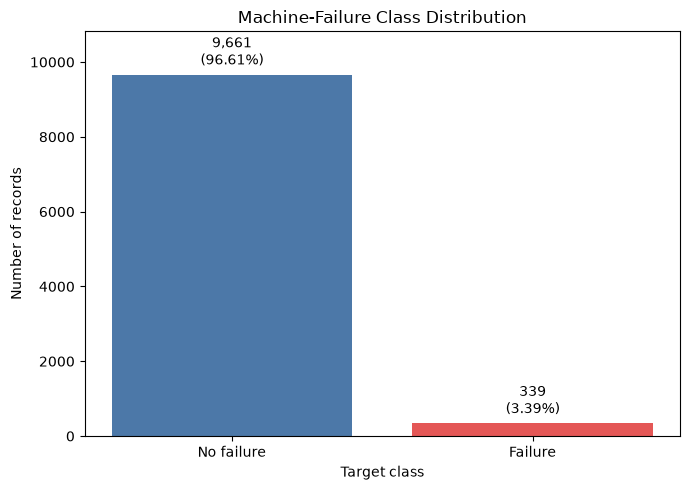

Figure saved to: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\figures\class_distribution.png


In [18]:
from pathlib import Path

# Create the bar chart
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["No failure", "Failure"],
    target_counts.values,
    color=["#4C78A8", "#E45756"]
)

# Display count and percentage above each bar
labels = [
    f"{count:,}\n({percentage:.2f}%)"
    for count, percentage in zip(
        target_counts.values,
        target_percentages.values
    )
]

ax.bar_label(bars, labels=labels, padding=4)

ax.set_title("Machine-Failure Class Distribution")
ax.set_xlabel("Target class")
ax.set_ylabel("Number of records")
ax.set_ylim(0, target_counts.max() * 1.12)

plt.tight_layout()

# Find the project folder and save the figure
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

figure_path = project_root / "figures" / "class_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

## 3. Class-Imbalance Visualization

The target distribution is visualized to show the difference between normal and failed machine records.

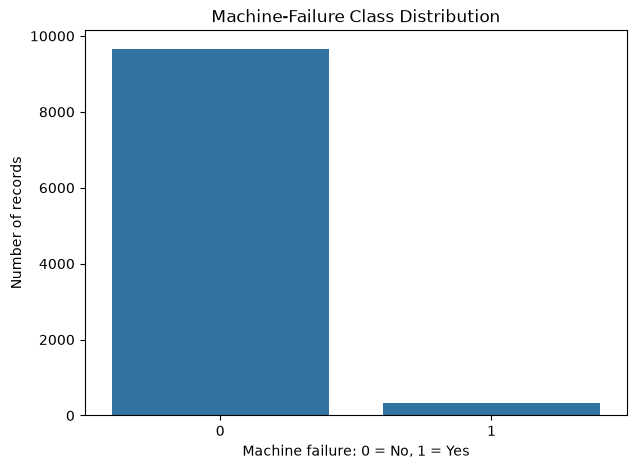

In [19]:
# Create an empty figure
plt.figure(figsize=(7, 5))

# Count classes 0 and 1 and draw their bars
sns.countplot(
    data=df,
    x="Machine failure"
)

# Add descriptions
plt.title("Machine-Failure Class Distribution")
plt.xlabel("Machine failure: 0 = No, 1 = Yes")
plt.ylabel("Number of records")

# Display the completed graph
plt.show()

## 4. Numerical Feature Summary

Descriptive statistics are calculated for the numerical machine measurements to understand their ranges, central values, and variability.

In [20]:
# Select only the numerical input features
numeric_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

# Calculate descriptive statistics
numeric_summary = (
    df[numeric_features]
    .describe()
    .T
    .round(2)
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.00,2.00,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.01,1.48,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.99,9.97,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.95,63.65,0.0,53.0,108.0,162.0,253.0


## 5. Failure Rate by Machine Type

The number and percentage of machine failures are compared across the L, M, and H product types.

In [21]:
# Group records by machine type and calculate failure information
type_analysis = df.groupby("Type")["Machine failure"].agg(
    Total_records="count",
    Failure_count="sum",
    Failure_rate="mean"
)

# Convert failure rate from a proportion to a percentage
type_analysis["Failure_rate"] = (
    type_analysis["Failure_rate"] * 100
).round(2)

# Give the percentage column a clearer name
type_analysis = type_analysis.rename(
    columns={"Failure_rate": "Failure rate (%)"}
)

type_analysis

,Total_records,Failure_count,Failure rate (%)
Type,,,
H,1003,21,2.09
L,6000,235,3.92
M,2997,83,2.77


## 6. Numerical Feature Distributions

Histograms are used to examine the distributions, ranges, and potential extreme values of the numerical input features.

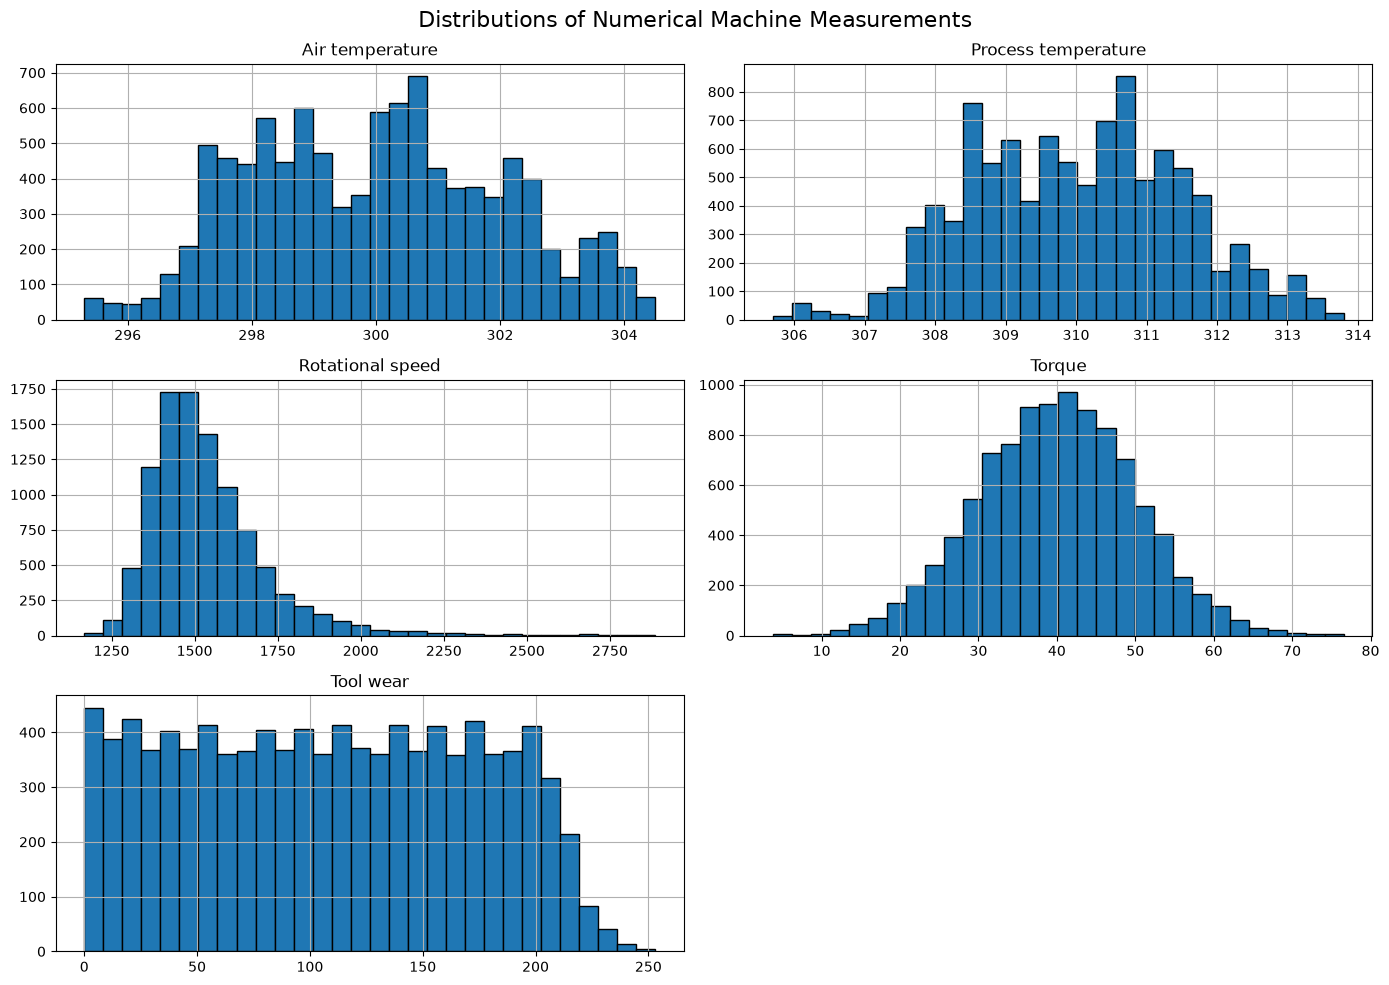

In [22]:
# Create one histogram for each numerical feature
df[numeric_features].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

# Add an overall title
plt.suptitle(
    "Distributions of Numerical Machine Measurements",
    fontsize=16
)

# Adjust spacing between graphs
plt.tight_layout()

# Display all graphs
plt.show()

## 7. Numerical Measurements by Failure Class

The average numerical measurements of normal and failed machines are compared to identify initial differences between the two classes.

In [23]:
# Calculate the mean of each feature separately for classes 0 and 1
failure_feature_means = (
    df.groupby("Machine failure")[numeric_features]
    .mean()
    .T
)

# Give the columns understandable names
failure_feature_means.columns = [
    "No failure mean",
    "Failure mean"
]

# Calculate the difference between failure and non-failure means
failure_feature_means["Difference"] = (
    failure_feature_means["Failure mean"]
    - failure_feature_means["No failure mean"]
)

# Display values with two decimal places
failure_feature_means.round(2)

,No failure mean,Failure mean,Difference
Air temperature,299.97,300.89,0.91
Process temperature,310.00,310.29,0.29
Rotational speed,1540.26,1496.49,-43.77
Torque,39.63,50.17,10.54
Tool wear,106.69,143.78,37.09


## 8. Feature Distributions by Failure Class

Boxplots compare the numerical feature distributions of normal and failed machines, including their medians, variability, and extreme values.

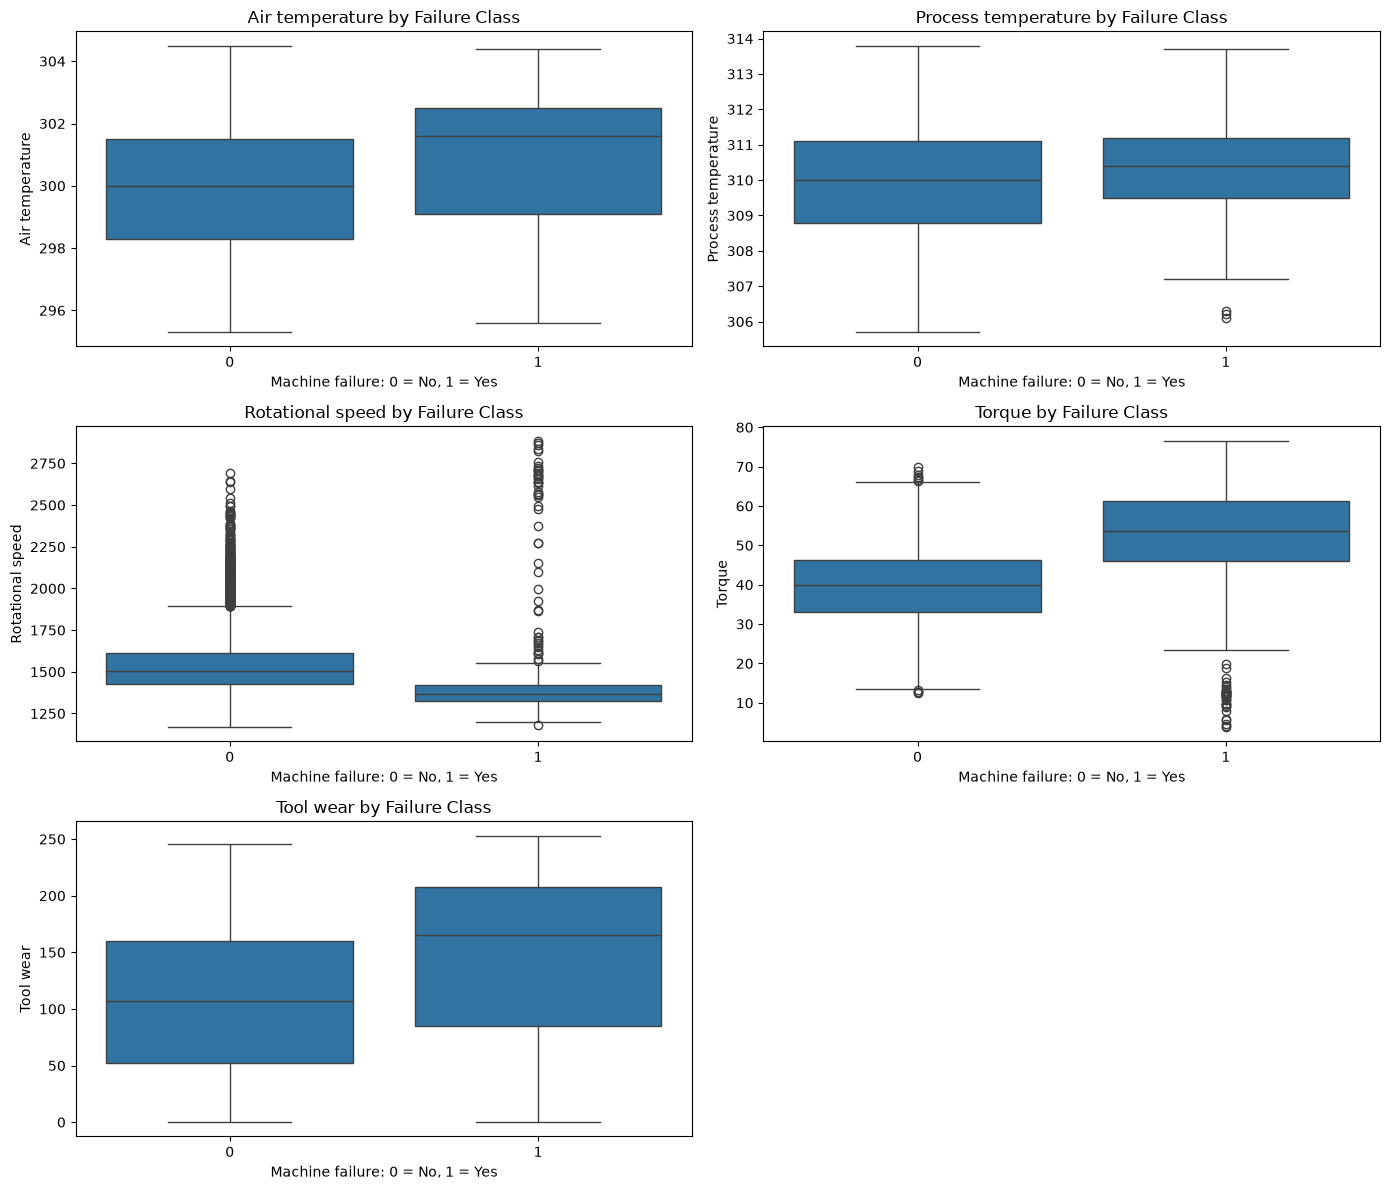

In [24]:
# Create six graph positions arranged as three rows and two columns
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12)
)

# Convert the graph-position grid into a simple list
axes = axes.flatten()

# Create one boxplot for every numerical feature
for position, feature in enumerate(numeric_features):
    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature,
        ax=axes[position]
    )

    axes[position].set_title(
        f"{feature} by Failure Class"
    )

    axes[position].set_xlabel(
        "Machine failure: 0 = No, 1 = Yes"
    )

# Hide the unused sixth graph position
axes[-1].axis("off")

# Adjust the graph spacing
plt.tight_layout()

# Display the graphs
plt.show()

## 9. Numerical Feature Correlation

A correlation heatmap is used to examine linear relationships among the numerical machine measurements and the machine-failure target.

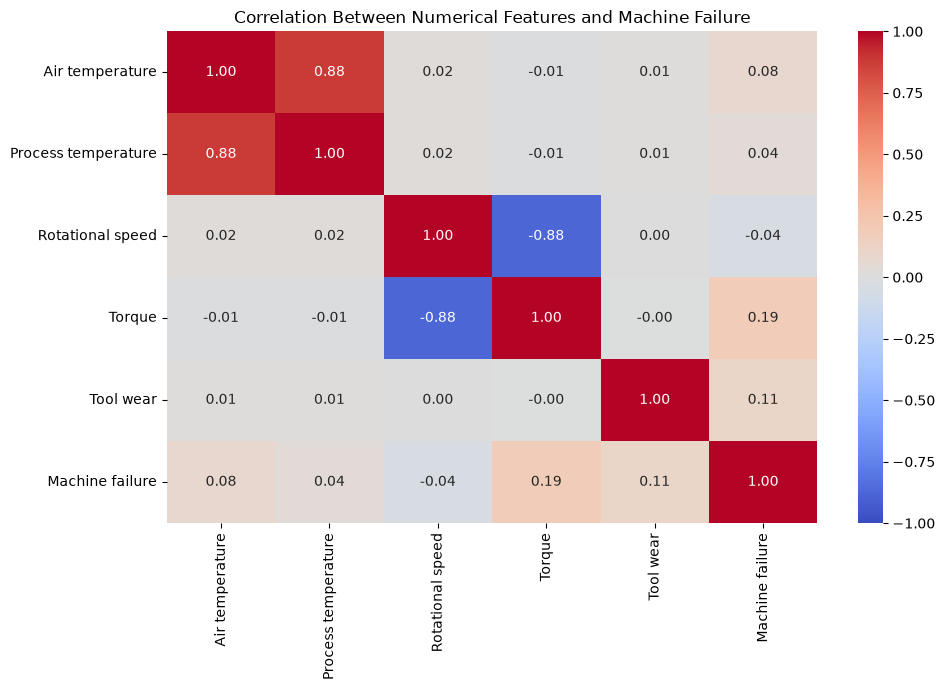

In [25]:
# Select numerical inputs and the main prediction target
correlation_columns = numeric_features + [
    "Machine failure"
]

# Calculate the correlation between every pair of columns
correlation_matrix = df[
    correlation_columns
].corr()

# Create the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Between Numerical Features and Machine Failure"
)

plt.tight_layout()
plt.show()

## 10. Statistical Comparison of Failure Classes

Welch's ANOVA tests whether the mean numerical measurements differ significantly between normal and failed machines. Cohen's d measures the practical size of each difference.

In [26]:
from scipy.stats import f_oneway

# Store the result produced for each feature
statistical_results = []

# Correct the significance level for five separate tests
corrected_alpha = 0.05 / len(numeric_features)

for feature in numeric_features:

    # Obtain values from normal and failed machines
    no_failure_values = df.loc[
        df["Machine failure"] == 0,
        feature
    ]

    failure_values = df.loc[
        df["Machine failure"] == 1,
        feature
    ]

    # Perform Welch's ANOVA
    f_statistic, p_value = f_oneway(
        no_failure_values,
        failure_values,
        equal_var=False
    )

    # Calculate pooled standard deviation
    n0 = len(no_failure_values)
    n1 = len(failure_values)

    pooled_standard_deviation = np.sqrt(
        (
            (n0 - 1) * no_failure_values.var()
            + (n1 - 1) * failure_values.var()
        )
        / (n0 + n1 - 2)
    )

    # Calculate Cohen's d effect size
    cohens_d = (
        failure_values.mean()
        - no_failure_values.mean()
    ) / pooled_standard_deviation

    # Save this feature's result
    statistical_results.append({
        "Feature": feature,
        "F statistic": f_statistic,
        "p-value": p_value,
        "Cohen's d": cohens_d,
        "Significant": p_value < corrected_alpha
    })

# Convert all results into a table
statistical_results = pd.DataFrame(
    statistical_results
)

statistical_results

,Feature,F statistic,p-value,Cohen's d,Significant
0,Air temperature,63.707579,1.950809e-14,0.457697,True
1,Process temperature,15.197430,1.151324e-04,0.198736,True
2,Rotational speed,4.354635,3.764748e-02,-0.244382,False
3,Torque,138.787549,3.635739e-27,1.076974,True
4,Tool wear,85.827064,1.906011e-18,0.585886,True


## 11. Failure-Mode Distribution

The individual failure mechanisms are counted to understand the engineering composition of the machine-failure target. These columns are used only for analysis and are excluded from model inputs to prevent data leakage.

In [27]:
# Store the failure-mode column names and full descriptions
failure_mode_names = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure"
}

# Count how many times each failure mode occurred
failure_mode_counts = (
    df[list(failure_mode_names.keys())]
    .sum()
    .rename(index=failure_mode_names)
    .sort_values(ascending=False)
)

# Convert the result into a table
failure_mode_table = failure_mode_counts.to_frame(
    name="Number of occurrences"
)

failure_mode_table

,Number of occurrences
Heat Dissipation Failure,115
Overstrain Failure,98
Power Failure,95
Tool Wear Failure,46
Random Failure,19


## 12. Exploratory Data Analysis Conclusions

The AI4I dataset contains 10,000 machine-operating records. No missing values were found in the original dataset.

The target is severely imbalanced:

- No failure: 9,661 records (96.61%)
- Failure: 339 records (3.39%)

Therefore, accuracy alone is unsuitable for evaluating failure prediction. Precision, recall, F1-score, PR-AUC, and confusion matrices will be emphasized.

Type L showed the highest observed failure rate among the three machine types.

The numerical analysis produced the following findings:

- Failed machines generally operate with higher torque.
- Failed machines generally have greater tool wear.
- Failed machines have slightly higher air and process temperatures.
- Failed machines have lower average rotational speed, but failures also appear at extreme high speeds.
- Air and process temperatures are strongly positively correlated.
- Rotational speed and torque are strongly negatively correlated.
- Torque has the largest effect-size difference between failure and non-failure groups.
- Tool wear has a medium effect-size difference.
- No individual feature can perfectly separate failure and non-failure records.

The columns TWF, HDF, PWF, OSF, and RNF describe failure mechanisms. They will be excluded from model inputs to prevent target leakage but retained for later error analysis.

The next stage will prepare the valid input features, encode the categorical Type column, split the data without leakage, and create preprocessing pipelines for Logistic Regression and Random Forest.